# Final project: N-body gravitational simulation

**Barnes-Hut tree with adaptive RK4 integration**

Eran Rehani &middot; Course 77315, Computational Physics

---

The notebook contains the numerical method, small executable checks, and saved
production results. It imports `nbody_solver.py` and displays selected functions
from that module. The written report is `report.pdf`.

Sections 1 to 5 cover the initial conditions, Barnes-Hut tree, adaptive RK4,
energy diagnostics, and reduced-size checks. Sections 6 to 8 load the saved
$N=5000$, 20 Gyr states from `figures/`. The production commands appear beside
those results.

In [1]:
import inspect, math, os, json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import nbody_solver as nb

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

def show(*objs):
    "Display the source of a function or class from nbody_solver."
    src = "\n\n".join(inspect.getsource(o) for o in objs)
    display(Markdown("```python\n" + src + "\n```"))

print("numba available:", nb._HAVE_NUMBA)
print(f"G = {nb.G} kpc^3 / (Msun Gyr^2),   1 kpc/Gyr = {nb.KM_PER_KPC_GYR} km/s")

numba available: True
G = 4.4996e-06 kpc^3 / (Msun Gyr^2),   1 kpc/Gyr = 0.9777922 km/s


## The problem

Given $N$ mass points with initial positions and velocities, evolve the system
under mutual gravity for a finite time. The assignment prescribes a softened
pair force,

$$\mathbf{f}_{ij} = -\frac{G m_i m_j}{(r_{ij}+S)^2}\,\frac{\mathbf{r}_{ij}}{r_{ij}},
\qquad \mathbf{r}_{ij} = \mathbf{r}_i - \mathbf{r}_j,$$

with $S$ a fixed distance that removes the singularity at zero separation. The
forces come from a Barnes-Hut tree and the trajectories from RK4 with adaptive
step size.

The assignment fixes the parameters below.

In [2]:
params = {
    "N": nb.N_MAIN, "M [Msun]": nb.M_TOT, "R [kpc]": nb.R_SPHERE,
    "S softening [kpc]": nb.S_SOFT, "theta": nb.THETA,
    "box [kpc]": f"+/- {nb.BOX/2:.0f}", "t_end [Gyr]": nb.T_END,
    "V [km/s]": nb.V_LIST,
}
for k, v in params.items():
    print(f"{k:>20} = {v}")

                   N = 5000
            M [Msun] = 100000000000.0
             R [kpc] = 50.0
   S softening [kpc] = 1.0
               theta = 1.0
           box [kpc] = +/- 666
         t_end [Gyr] = 20.0
            V [km/s] = (80.0, 95.0, 65.0)


## 1. Initial conditions

Uniform volume density requires $r=Ru^{1/3}$ with $u$ uniform on $[0,1]$;
sampling $r$ uniformly would concentrate particles near the centre. The sampler
uses $\cos\vartheta=2u-1$ and $\varphi=2\pi u$ for isotropic directions.

Each Cartesian velocity component is normal with mean zero and
$\sigma = V/\sqrt{3}$, which gives $\langle v^2\rangle^{1/2} = V$.

In [3]:
show(nb.rand_dir, nb.init_conditions)

```python
def rand_dir(n, rng):
    """Return n isotropically distributed unit vectors."""
    u = rng.random(n)
    cos_t = 2.0 * u - 1.0
    sin_t = np.sqrt(np.maximum(0.0, 1.0 - cos_t * cos_t))
    phi = 2.0 * np.pi * rng.random(n)
    return np.column_stack([sin_t * np.cos(phi),
                            sin_t * np.sin(phi),
                            cos_t])


def init_conditions(N, V_kms, seed=SEED, rng=None):
    """Sample a uniform sphere and Maxwell-Boltzmann velocities.

    Return positions in kpc, velocities in kpc/Gyr, and masses in M_sun.
    """
    if rng is None:
        rng = np.random.default_rng(seed)
    # Uniform volume density requires r = R * u^(1/3).
    u = rng.random(N)
    r = R_SPHERE * u ** (1.0 / 3.0)
    pos = r[:, None] * rand_dir(N, rng)
    # Each velocity component has sigma = V / sqrt(3).
    V = V_kms / KM_PER_KPC_GYR
    sigma = V / math.sqrt(3.0)
    vel = rng.normal(0.0, sigma, size=(N, 3))
    # Remove only bulk velocity. Translating the sampled positions would move
    # some particles outside the specified sphere centred on the box origin.
    vel -= vel.mean(axis=0)
    m = np.full(N, M_TOT / N)
    return pos, vel, m

```

max radius      = 49.9961 kpc      (must be <= 50.0)
RMS speed       = 80.235 km/s     (requested 80)
particle mass   = 2e+07 Msun
net velocity    = 7.31e-15 kpc/Gyr


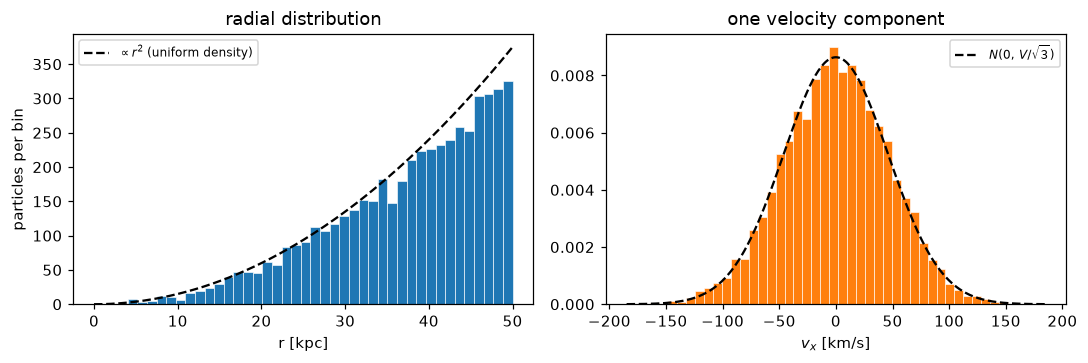

In [4]:
pos0, vel0, m = nb.init_conditions(nb.N_MAIN, 80.0, seed=nb.SEED)
r = np.linalg.norm(pos0, axis=1)
v_rms = np.sqrt(np.mean(np.sum(vel0**2, axis=1))) * nb.KM_PER_KPC_GYR

print(f"max radius      = {r.max():.4f} kpc      (must be <= {nb.R_SPHERE})")
print(f"RMS speed       = {v_rms:.3f} km/s     (requested 80)")
print(f"particle mass   = {m[0]:.3g} Msun")
print(f"net velocity    = {np.linalg.norm(vel0.mean(axis=0)):.2e} kpc/Gyr")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].hist(r, bins=40, color="C0", edgecolor="white", linewidth=0.4)
rr = np.linspace(0, nb.R_SPHERE, 200)
ax[0].plot(rr, 3*nb.N_MAIN*rr**2/nb.R_SPHERE**3 * (nb.R_SPHERE/40),
           "k--", lw=1.5, label=r"$\propto r^2$ (uniform density)")
ax[0].set_xlabel("r [kpc]")
ax[0].set_ylabel("particles per bin")
ax[0].set_title("radial distribution")
ax[0].legend(fontsize=8)

ax[1].hist(vel0[:, 0]*nb.KM_PER_KPC_GYR, bins=40, density=True,
           color="C1", edgecolor="white", linewidth=0.4)
s = 80.0/math.sqrt(3)
vv = np.linspace(-4*s, 4*s, 300)
ax[1].plot(vv, np.exp(-vv**2/(2*s**2))/(s*math.sqrt(2*math.pi)), "k--", lw=1.5,
           label=r"$N(0,\,V/\sqrt{3})$")
ax[1].set_xlabel(r"$v_x$ [km/s]")
ax[1].set_title("one velocity component")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. The octree

A cubic root cell encloses every particle. Any cell holding more than one
particle is split into eight octants, recursively, so each leaf ends up with at
most one particle. Every cell records its particle count, total mass, centre of
mass, and its size $L$.

Here $L$ is the main diagonal, $L = \sqrt{3}\,l$ for side length $l$. Standard
Barnes-Hut descriptions usually use $l$, which reverses the direction in which
the opening parameter changes the accuracy.

Particles at identical coordinates never separate under further subdivision.
The builder stores them in one childless cell. Their mutual force is zero, and
an external target sees their combined mass at the same point.

In [5]:
show(nb.Cell, nb.build_tree)

```python
class Cell:
    __slots__ = ("cx", "cy", "cz", "side", "half", "diag",
                 "mass", "comx", "comy", "comz", "count",
                 "children", "pidx")

    def __init__(self, cx, cy, cz, side):
        self.cx, self.cy, self.cz = cx, cy, cz
        self.side = side
        self.half = 0.5 * side
        self.diag = side * math.sqrt(3.0)  # L in the assignment
        self.mass = 0.0
        self.comx = self.comy = self.comz = 0.0
        self.count = 0
        self.children = None
        self.pidx = -1  # particle index for a one-particle leaf


def build_tree(pos, mass):
    """Build a Barnes-Hut octree and return its root cell."""
    pmin = pos.min(axis=0)
    pmax = pos.max(axis=0)
    ctr = 0.5 * (pmin + pmax)
    side = (pmax - pmin).max() * 1.0001  # keep boundary points inside
    if side <= 0:
        side = 1.0
    idx = np.arange(len(mass))
    root = Cell(ctr[0], ctr[1], ctr[2], side)
    _build_subtree(root, pos, mass, idx)
    return root

```

In [6]:
show(nb._build_subtree)

```python
def _build_subtree(cell, pos, mass, idx):
    """Populate a cell recursively from the particle indices in idx."""
    n = len(idx)
    cell.count = n
    if n == 0:
        return
    m = mass[idx]
    cell.mass = m.sum()
    w = m / cell.mass
    cell.comx = float((w * pos[idx, 0]).sum())
    cell.comy = float((w * pos[idx, 1]).sum())
    cell.comz = float((w * pos[idx, 2]).sum())
    if n == 1:
        cell.pidx = int(idx[0])
        return
    h = cell.half
    cx, cy, cz = cell.cx, cell.cy, cell.cz
    # The three comparison bits identify one of the eight octants.
    px = pos[idx, 0]
    py = pos[idx, 1]
    pz = pos[idx, 2]
    key = ((px > cx).astype(int) +
           2 * (py > cy).astype(int) +
           4 * (pz > cz).astype(int))
    if (key == key[0]).all():
        # A close pair can remain in one octant through several levels. Exactly
        # coincident points never separate, so store them as one childless cell.
        # Their mutual force is zero and an external target sees their total mass.
        if float((pos[idx].max(axis=0) - pos[idx].min(axis=0)).max()) == 0.0:
            cell.children = []
            return
    cell.children = []
    child_side = cell.side * 0.5
    off = child_side * 0.5
    for k in range(8):
        sub = idx[key == k]
        if len(sub) == 0:
            cell.children.append(None)
            continue
        ox = cx + (off if (k & 1) else -off)
        oy = cy + (off if (k & 2) else -off)
        oz = cz + (off if (k & 4) else -off)
        child = Cell(ox, oy, oz, child_side)
        _build_subtree(child, pos, mass, sub)
        cell.children.append(child)

```

## 3. The tree walk

To find the force on one particle, descend from the root:

- a cell holding **one** particle contributes the direct softened pair force,
  unless it *is* the target;
- if the target lies **inside** the cell, always open it, so the target's own
  mass never enters a centre-of-mass approximation;
- otherwise measure $D$, the distance from the target to the cell's centre of
  mass, and compare with $L$: open the cell when $D/L < \theta$, and replace it
  by its total mass at its centre of mass when $D/L \geq \theta$.

The assignment uses $D/L$ with the cell diagonal. Raising $\theta$ therefore
opens more cells, opposite to the usual $l/D \leq \theta$ convention. The two
parameters satisfy
$\theta_{\text{side}} = 1/(\sqrt{3}\,\theta_{\text{diagonal}})$, so the assigned
$\theta = 1$ corresponds to a fairly strict $0.577$.

In [7]:
show(nb._particle_in_cell, nb._walk_acc)

```python
def _particle_in_cell(ri, cell):
    return (abs(ri[0] - cell.cx) <= cell.half + 1e-9 and
            abs(ri[1] - cell.cy) <= cell.half + 1e-9 and
            abs(ri[2] - cell.cz) <= cell.half + 1e-9)


def _walk_acc(cell, ri, mi, theta, S, G, m_arr, pos, acc):
    if cell is None or cell.count == 0:
        return
    if cell.count == 1:
        j = cell.pidx
        if j < 0:
            return
        dx = ri[0] - pos[j, 0]
        dy = ri[1] - pos[j, 1]
        dz = ri[2] - pos[j, 2]
        r2 = dx * dx + dy * dy + dz * dz
        r = math.sqrt(r2)
        if r == 0.0:
            return
        rsoft = r + S
        fac = -G * m_arr[j] / (rsoft * rsoft * r)
        acc[0] += fac * dx
        acc[1] += fac * dy
        acc[2] += fac * dz
        return
    if _particle_in_cell(ri, cell):
        for ch in cell.children:
            _walk_acc(ch, ri, mi, theta, S, G, m_arr, pos, acc)
        return
    dx = ri[0] - cell.comx
    dy = ri[1] - cell.comy
    dz = ri[2] - cell.comz
    D = math.sqrt(dx * dx + dy * dy + dz * dz)
    if D / cell.diag < theta and cell.children:
        for ch in cell.children:
            _walk_acc(ch, ri, mi, theta, S, G, m_arr, pos, acc)
    else:
        rsoft = D + S
        fac = -G * cell.mass / (rsoft * rsoft * D)
        acc[0] += fac * dx
        acc[1] += fac * dy
        acc[2] += fac * dz

```

### Two-dimensional example

The figure applies the same rules to a drawable two-dimensional quadtree. Cells
subdivide in dense regions. Red points contribute direct pair forces to the black
target; green stars mark accepted cell centres of mass.

force on the target: 12 direct pair terms + 14 cell terms, in place of 59 pair terms


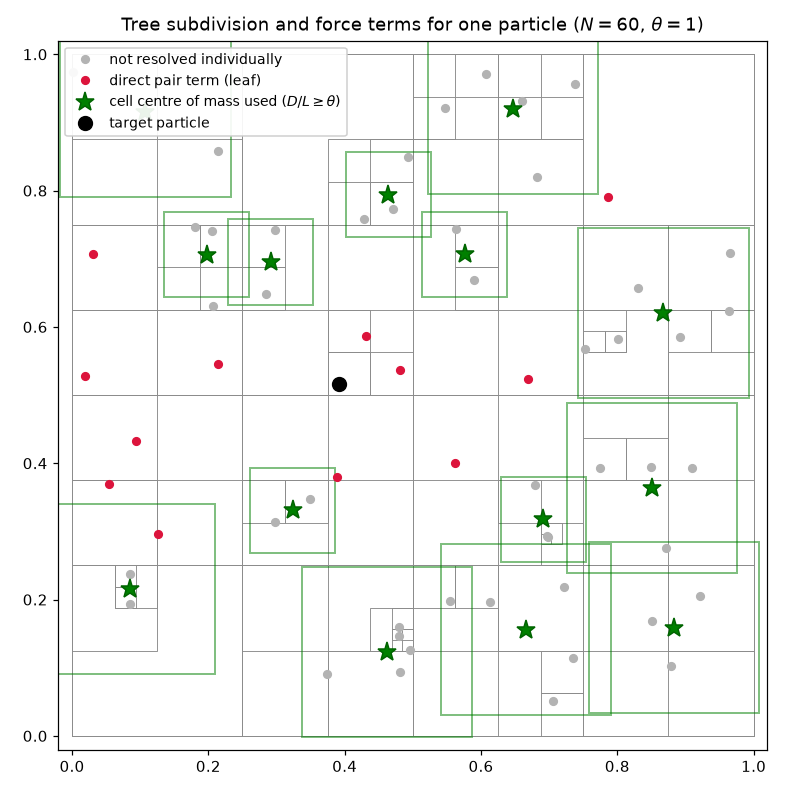

In [8]:
from IPython.display import Image
path = os.path.join(nb.FIG_DIR, "fig_tree_nb.png")
n_direct, n_lumped = nb.plot_tree_demo(path, n=60, theta=nb.THETA, seed=3)
print(f"force on the target: {n_direct} direct pair terms + {n_lumped} cell terms, "
      f"in place of 59 pair terms")
display(Image(filename=path, width=620))

### Accuracy against a direct sum

The direct $O(N^2)$ calculation provides the reference for the tree error. Both
methods evaluate the same particle configuration.

In [9]:
rng = np.random.default_rng(11)
N_t = 2000
u = rng.random(N_t)
p = (nb.R_SPHERE * u**(1/3))[:, None] * nb.rand_dir(N_t, rng)
mt = np.full(N_t, nb.M_TOT/N_t)

a_dir = nb.compute_direct_acc(p, mt, S=nb.S_SOFT)
norm = np.linalg.norm(a_dir)

rows = []
for th in (2.0, 1.5, 1.0, 0.8, 0.6, 0.4):
    a_tree = nb.compute_tree_acc(p, mt, theta=th, S=nb.S_SOFT)
    rows.append((th, 1/(math.sqrt(3)*th),
                 float(np.linalg.norm(a_tree - a_dir)/norm)))

print(f"{'theta (diag)':>13} {'theta (side)':>13} {'L2 rel. error':>15}")
for th, ths, l2 in rows:
    mark = "   <- assigned" if th == 1.0 else ""
    print(f"{th:>13.1f} {ths:>13.3f} {l2:>15.2e}{mark}")

 theta (diag)  theta (side)   L2 rel. error
          2.0         0.289        1.13e-03
          1.5         0.385        3.00e-03
          1.0         0.577        9.42e-03   <- assigned
          0.8         0.722        1.68e-02
          0.6         0.962        3.73e-02
          0.4         1.443        1.11e-01


## 4. Adaptive RK4

Writing the state as $\mathbf{y} = (\mathbf{r}_1 \ldots \mathbf{r}_N,
\mathbf{v}_1 \ldots \mathbf{v}_N)$, the equations of motion are
$\dot{\mathbf{r}}_i = \mathbf{v}_i$ and $\dot{\mathbf{v}}_i = \mathbf{a}_i$.

The assignment prescribes the step control directly: compare one step of length
$h$ with two of length $h/2$. It also names the error measure, the largest
displacement error of any mass point,

$$\mathrm{err} = \max_i \lVert \mathbf{r}_{i,\text{half}} - \mathbf{r}_{i,\text{full}} \rVert.$$

The controller accepts a step when $\mathrm{err} \leq \mathrm{tol}$, then uses
Richardson extrapolation to remove the leading error term. The full step and first
half step reuse their identical first stage, so each proposal costs eleven force
evaluations. Every remaining evaluation rebuilds the tree because its stage
positions differ.

In [10]:
show(nb.rk_step)

```python
def rk_step(f, t, y, h, k1=None):
    """Advance y by one fourth-order Runge-Kutta step."""
    if k1 is None:
        k1 = f(t, y)
    k2 = f(t + h / 2.0, y + (h / 2.0) * k1)
    k3 = f(t + h / 2.0, y + (h / 2.0) * k2)
    k4 = f(t + h, y + h * k3)
    return y + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

```

A softened circular binary with unequal masses checks the integrator against a
known period and separation. After two periods, it should return to its initial
separation with negligible energy drift.

two orbits in 488 accepted steps
relative energy drift = 1.29e-10
final separation      = 1.00000000  (initial 1.0)


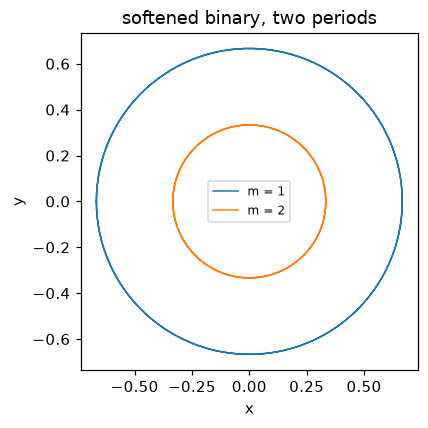

In [11]:
G_t, S_t = 1.0, 0.01
mb = np.array([1.0, 2.0])
sep = 1.0
omega = math.sqrt(G_t*mb.sum()/(sep*(sep + S_t)**2))
pb = np.array([[-2/3, 0.0, 0.0], [1/3, 0.0, 0.0]])
vb = np.array([[0.0, -omega*2/3, 0.0], [0.0, omega/3, 0.0]])
y0 = np.concatenate([pb.ravel(), vb.ravel()])
rhs = lambda t, y: nb.nbody_rhs(t, y, 2, mb, nb.THETA, S_t, G_t)

E0 = nb.kinetic_energy(vb, mb) + nb.grav_energy_direct(pb, mb, S=S_t, Gval=G_t)
period = 2*math.pi/omega
ts, ys, info, _ = nb.rk_adaptive_nbody(rhs, 0.0, y0, 2*period, 1e-10,
                                       h_min=1e-6, h_max=0.05)
pf = ys[-1][:6].reshape(2, 3)
vf = ys[-1][6:].reshape(2, 3)
Ef = nb.kinetic_energy(vf, mb) + nb.grav_energy_direct(pf, mb, S=S_t, Gval=G_t)

print(f"two orbits in {info['n_steps']} accepted steps")
print(f"relative energy drift = {abs(Ef-E0)/abs(E0):.2e}")
print(f"final separation      = {np.linalg.norm(pf[1]-pf[0]):.8f}  (initial {sep})")

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(ys[:, 0], ys[:, 1], lw=1, label="m = 1")
ax.plot(ys[:, 3], ys[:, 4], lw=1, label="m = 2")
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("softened binary, two periods")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Energy, and the particles that leave

The diagnostics are

$$E_k = \tfrac12 \sum_i m_i v_i^2, \qquad
E_g = \tfrac12 \sum_i m_i \Phi_i, \qquad
\Phi_i = -G\sum_{j \neq i} \frac{m_j}{r_{ij}+S},$$

with $\Phi_i$ evaluated through the same tree and opening rule as the forces
once $N$ is large, and by direct summation below 1500 particles.

The solver removes any particle that leaves the $\pm 666$ kpc box. Removal
deletes its kinetic energy and pair terms from the sums. The code records
each event, and the energy plots include a retained-particle curve and a curve
that restores the energy recorded at escape. The corrected curve better isolates
integration drift from deletion jumps.

The algebraic difference contains both escaper-escaper and escaper-retained
terms in the chosen estimator. At production size each of the two $E_g$ values
is an independent Barnes-Hut approximation, so this is not an exact direct-pair
split.

In [12]:
show(nb.kinetic_energy, nb.grav_energy)

```python
def kinetic_energy(vel, m):
    return 0.5 * (m * (vel * vel).sum(axis=1)).sum()


def grav_energy(pos, m, theta=THETA, S=S_SOFT, Gval=G):
    """Return Eg from a direct sum for small N and the tree for large N."""
    if len(m) == 0:
        return 0.0
    if len(m) <= DIRECT_EG_MAX_N:
        return grav_energy_direct(pos, m, S, Gval)
    return grav_energy_tree(pos, m, theta, S, Gval)

```

### Reduced-size check

This reduced-$N$ run exercises initialization, integration, escape bookkeeping,
and snapshot storage without loading a production state.

In [13]:
demo = nb.run_one(80.0, N=400, t_end=5.0, tol=0.1332,
                  snapshot_times=[0.0, 2.5, 5.0], verbose=True)
E0d = demo["E0"]
drift = (demo["etot_log"] - E0d)/E0d
print(f"\nrelative energy drift over 5 Gyr: {abs(drift).max():.2e}")

[V=80.0] N=400  Ek0=3.5032e+14  Eg0=-5.1898e+14  E0=-1.6865e+14  virial 2Ek/|Eg|=1.350


[V=80.0] done: 121 steps, 60 rejected, 18.1s, final N=400

relative energy drift over 5 Gyr: 1.71e-03


## 6. Results

The cells below load the saved $N=5000$, 20 Gyr production states for all three
velocities from `figures/`. Regenerate those states with

```bash
python nbody_solver.py --tol=0.1332              # Section 5 of the report
python nbody_solver.py --tol=133.2 --tag=eps01   # Appendix A
```

### Integration tolerance

The assignment states the RK4 accuracy as
$\varepsilon = 0.1$ *in units of the calculation box*, which is a permitted step
error of $0.1 \times 1332 = 133.2$ kpc, larger than the cluster itself. At that
setting the controller never shortens a step, and the final escape-corrected
energy shifts by 9 to 35 percent. Section 6 uses $0.1332$ kpc. Section 8 and
Appendix A of the report contain every output at the assigned value.

In [14]:
runs = {V: nb.load_run_npz(V) for V in (65.0, 80.0, 95.0)}
main = runs[80.0]
summary = json.load(open(os.path.join(nb.FIG_DIR, "summary.json")))

print(f"{'V [km/s]':>9} {'2Ek0/|Eg0|':>12} {'removed':>9} {'retained':>10} {'steps':>7}")
for run in sorted(summary["runs"], key=lambda r: r["V"]):
    print(f"{run['V']:>9.0f} {2*run['E0_k']/abs(run['E0_g']):>12.3f} "
          f"{run['N0']-run['Nf']:>9d} {run['Nf']:>10d} {run['n_steps']:>7d}")

V_vir = math.sqrt(3*nb.G*nb.M_TOT/(5*nb.R_SPHERE)) * nb.KM_PER_KPC_GYR
print(f"\nvirial velocity for a uniform sphere: sqrt(3GM/5R) = {V_vir:.2f} km/s")
print("so V=65 starts bound and sub-virial, V=80 and V=95 start super-virial")

 V [km/s]   2Ek0/|Eg0|   removed   retained   steps
       65        0.849        20       4980     352
       80        1.286       167       4833     310
       95        1.814       758       4242     262

virial velocity for a uniform sphere: sqrt(3GM/5R) = 71.85 km/s
so V=65 starts bound and sub-virial, V=80 and V=95 start super-virial


### (a) Positions in three dimensions

The six panels show the $V=80$ km/s run with limits centered on the cluster.
Using the full $\pm666$ kpc box would hide its structure. Each title reports the
fraction of particles outside the plotted frame.

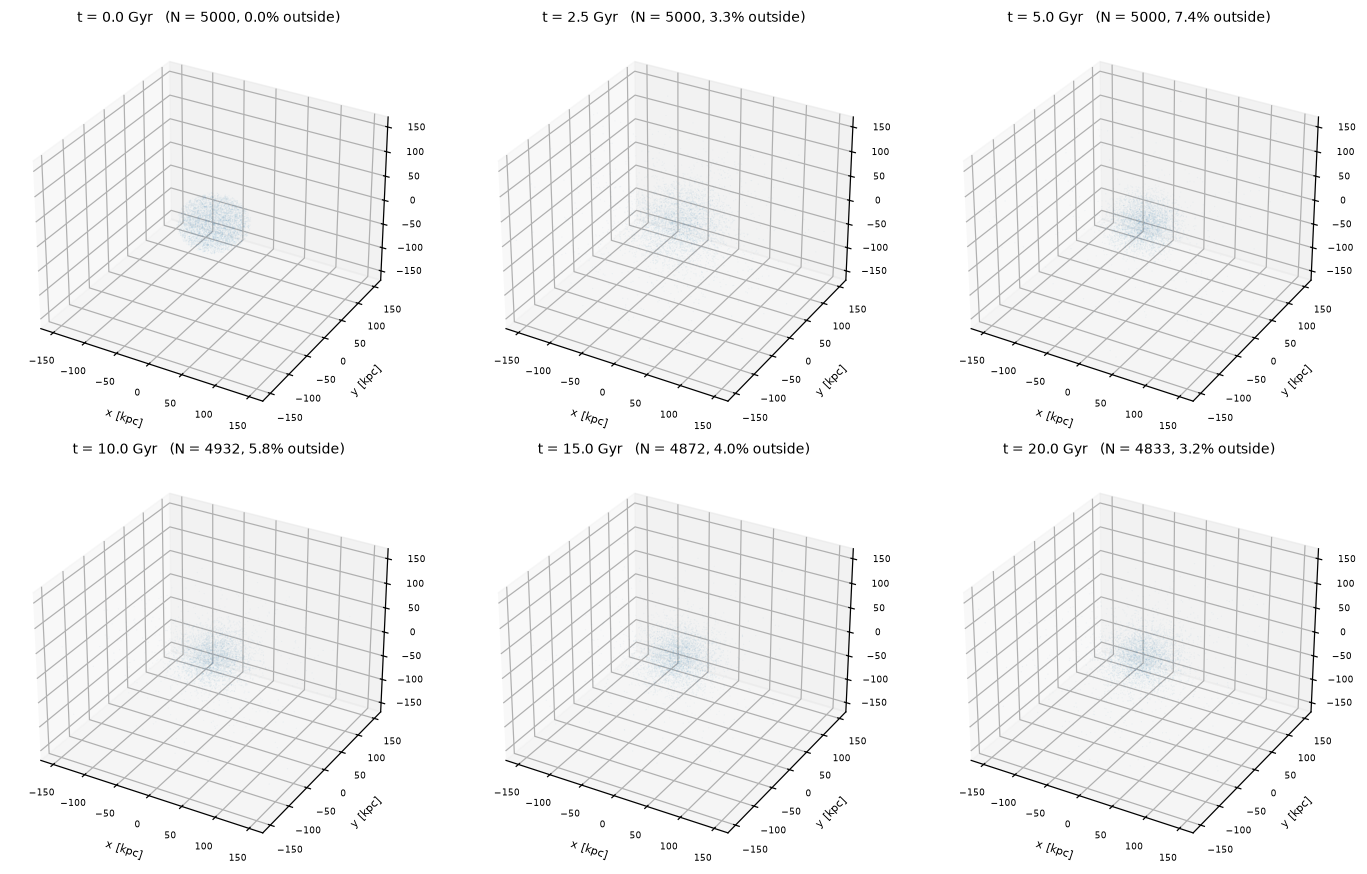

In [15]:
snaps = sorted(t for t, v in main["snaps"].items() if v is not None)

fig = plt.figure(figsize=(13, 8))
lim = 170
for k, t in enumerate(snaps):
    p = main["snaps"][t][0]
    ax = fig.add_subplot(2, 3, k+1, projection="3d")
    inside = np.abs(p).max(axis=1) < lim
    ax.scatter(p[inside, 0], p[inside, 1], p[inside, 2], s=0.7, alpha=0.25,
               color="C0", linewidths=0)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_title(f"t = {t:.1f} Gyr   (N = {len(p)}, "
                 f"{100*(1-inside.mean()):.1f}% outside)", fontsize=9)
    ax.set_xlabel("x [kpc]", fontsize=7)
    ax.set_ylabel("y [kpc]", fontsize=7)
    ax.tick_params(labelsize=6)
plt.tight_layout()
plt.show()

Within 2.5 Gyr, the initially uniform sphere develops a dense core and an
extended halo. The halo continues to spread as the super-virial system expands,
loses its fastest particles, and settles through violent relaxation.

### (b) Energy conservation

$(E(t) - E_0)/E_0$ against time, with both accountings.

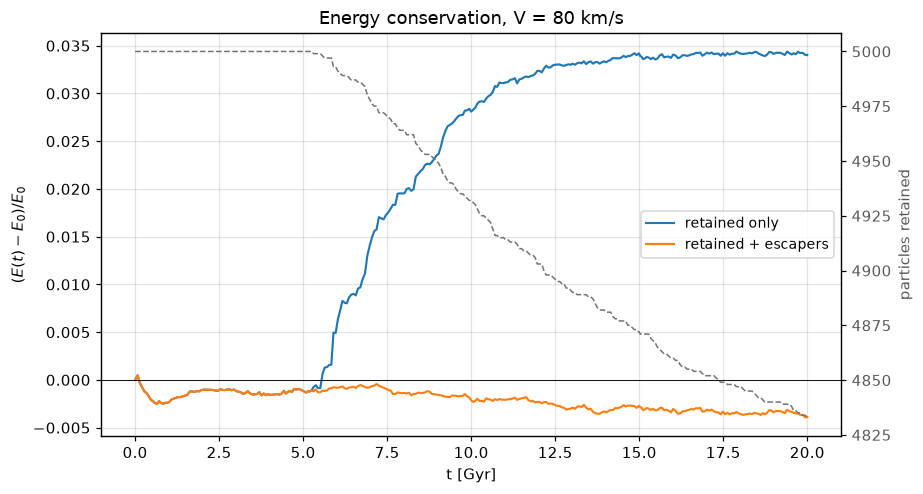

first escape at t = 5.31 Gyr; 167 particles leave in total
final drift, retained only        : +0.0340
final drift, escapers added back  : -0.0039
largest excursion of the corrected curve: 3.92e-03


In [16]:
t = main["t_log"]
E0 = main["E0"]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(t, (main["eret_log"]-E0)/E0, lw=1.4, color="C0", label="retained only")
ax.plot(t, (main["etot_log"]-E0)/E0, lw=1.4, color="C1", label="retained + escapers")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("t [Gyr]")
ax.set_ylabel(r"$(E(t)-E_0)/E_0$")
ax.set_title("Energy conservation, V = 80 km/s")
ax.grid(alpha=0.35)
ax2 = ax.twinx()
ax2.plot(t, main["n_log"], "--", lw=1.0, color="0.45")
ax2.set_ylabel("particles retained", color="0.35")
ax2.tick_params(axis="y", labelcolor="0.35")
ax.legend(fontsize=9, loc="center right")
plt.tight_layout()
plt.show()

esc = np.asarray(main["esc_log"])
print(f"first escape at t = {esc[0][0]:.2f} Gyr; {int(esc[:,1].sum())} particles leave in total")
print(f"final drift, retained only        : {(main['eret_log'][-1]-E0)/E0:+.4f}")
print(f"final drift, escapers added back  : {(main['etot_log'][-1]-E0)/E0:+.4f}")
print(f"largest excursion of the corrected curve: {np.abs((main['etot_log']-E0)/E0).max():.2e}")

The curves separate after the first escape at 5.3 Gyr. The retained curve ends
at $+0.034$, mostly because removal deletes negative binding terms from $E_g$.
Since $E_0<0$, this shifts the plotted ratio upward. Restoring the recorded
escape energy limits the 20 Gyr drift to four parts in a thousand.

### (c) The virial ratio

$-2E_k/E_g$ against time. The assignment asks for two curves, one adding back
the energy of the escaped particles at the value it had when they left, and one
without.

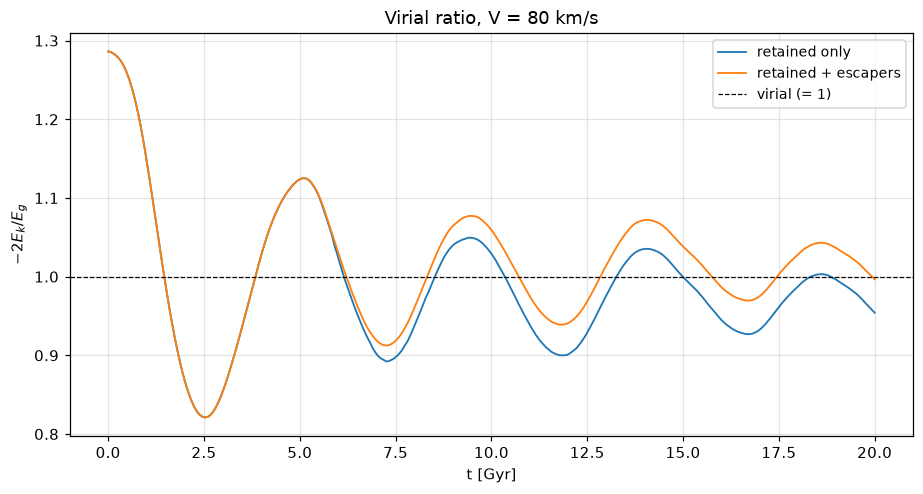

 V [km/s]    start   end (retained)
       65    0.849            0.960
       80    1.286            0.954
       95    1.814            0.937


In [17]:
Ek, Eg = (
    main["ek_log"],
    main["eg_log"],
)
cek = np.zeros(len(t))
ceg = np.zeros(len(t))
a = b = 0.0
j = 0
esc = main["esc_log"]
for k in range(len(t)):
    while j < len(esc) and esc[j][0] <= t[k] + 1e-9:
        a += esc[j][2]
        b += esc[j][3]
        j += 1
    cek[k], ceg[k] = a, b

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(t, -2*Ek/Eg, lw=1.2, label="retained only")
ax.plot(t, -2*(Ek+cek)/(Eg+ceg), lw=1.2, label="retained + escapers")
ax.axhline(1.0, color="k", ls="--", lw=0.8, label="virial (= 1)")
ax.set_xlabel("t [Gyr]")
ax.set_ylabel(r"$-2E_k/E_g$")
ax.set_title("Virial ratio, V = 80 km/s")
ax.grid(alpha=0.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'V [km/s]':>9} {'start':>8} {'end (retained)':>16}")
for V in (65.0, 80.0, 95.0):
    rr = runs[V]
    print(f"{V:>9.0f} {-2*rr['ek_log'][0]/rr['eg_log'][0]:>8.3f} "
          f"{-2*rr['ek_log'][-1]/rr['eg_log'][-1]:>16.3f}")

The system starts well above equilibrium at $1.286$, falls straight past the
virial value to $0.82$ by 2.5 Gyr, then rings back through one with a decaying
amplitude. Successive maxima at 5.1, 9.4, 14.0 and 18.6 Gyr give a period of
about 4.5 Gyr, a few crossing times.

All three velocities end near one, but by different routes: $V = 65$ starts
sub-virial and contracts, losing only 20 particles; $V = 95$ starts close to
unbinding and reaches equilibrium mainly by evaporating 15 percent of its mass.

### (d) Density profiles and King fits

The analysis uses 25 logarithmic shells about the retained center of mass, with
Poisson errors $\rho_j/\sqrt{N_j}$, and fits

$$\rho(r) = \frac{\rho_c}{\left[1 + (r/r_c)^{\alpha}\right]^{\beta}}.$$

The fit runs in $\log \rho$ with $\log \rho_c$ and $\log r_c$ as free variables,
so both stay positive, and scans several starting values for $\alpha$ and
$\beta$.

In [18]:
show(nb.density_profile, nb.king_model)

```python
def density_profile(pos, m, n_bins=25, r_min=None, r_max=None, center=None):
    """Return a COM-centred spherical density profile in logarithmic bins."""
    pos = np.asarray(pos, dtype=float)
    m = np.asarray(m, dtype=float)
    if len(pos) != len(m) or len(m) == 0:
        raise ValueError("pos and m must describe at least one particle")
    if center is None:
        center = np.average(pos, axis=0, weights=m)
    r = np.linalg.norm(pos - np.asarray(center), axis=1)
    if r_min is None:
        positive_r = r[r > 0]
        r_min = max(positive_r.min() if len(positive_r) else 1e-3, 1e-3)
    if r_max is None:
        r_max = r.max()
    if r_max <= r_min:
        r_max = r_min * (1.0 + 1e-6)
    bins = np.logspace(np.log10(r_min), np.log10(r_max), n_bins + 1)
    # Reconstructing a logarithmic endpoint can move it inward by one ULP.
    # Expanding only the boundary edges keeps the occupied interval closed.
    bins[0] = np.nextafter(bins[0], -np.inf)
    bins[-1] = np.nextafter(bins[-1], np.inf)
    vol = (4.0 / 3.0) * np.pi * (bins[1:] ** 3 - bins[:-1] ** 3)
    counts, _ = np.histogram(r, bins=bins)
    shell_mass, _ = np.histogram(r, bins=bins, weights=m)
    shell_mass_variance, _ = np.histogram(r, bins=bins, weights=m * m)
    rho = shell_mass / vol
    rho_err = np.sqrt(shell_mass_variance) / vol
    r_centers = np.sqrt(bins[:-1] * bins[1:])
    mask = counts > 0
    return r_centers[mask], rho[mask], rho_err[mask]


def king_model(r, rho_c, r_c, alpha, beta):
    return rho_c / (1.0 + (r / r_c) ** alpha) ** beta

```

## 7. Common King shape at V = 65, 80, and 95 km/s

The assignment requires identical $\alpha$ and $\beta$ for all three cases. The
$V=80$ run determines all four parameters; the other two fits vary only
$\rho_c$ and $r_c$.

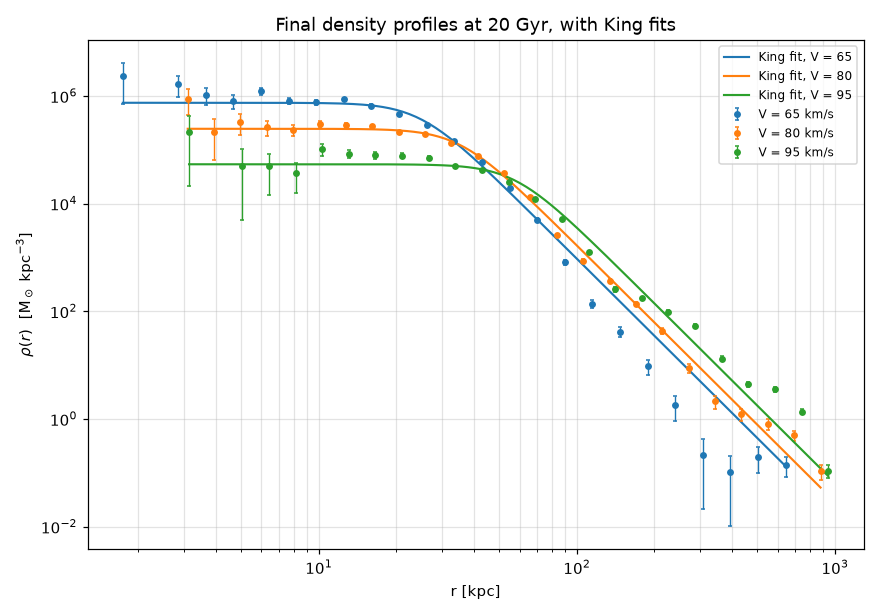

In [19]:
fits = {}
fix_ab = None
for V in (80.0, 95.0, 65.0):          # 80 first: it sets alpha and beta
    d = runs[V]
    rc, rho, rerr = nb.density_profile(d["pos_final"], d["m"])
    popt, perr = nb.fit_king(rc, rho, rerr, fix_alpha_beta=fix_ab)
    pred = nb.king_model(rc, *popt)
    chi2 = float(np.sum(((np.log(rho)-np.log(pred))/(rerr/rho))**2))
    ndf = len(rho) - (4 if fix_ab is None else 2)
    fits[V] = dict(rc=rc, rho=rho, rerr=rerr, popt=popt, perr=perr,
                   chi2=chi2, ndf=ndf)
    if fix_ab is None:
        fix_ab = (float(popt[2]), float(popt[3]))

fig, ax = plt.subplots(figsize=(8, 5.6))
colors = {65.0: "C0", 80.0: "C1", 95.0: "C2"}
for V in (65.0, 80.0, 95.0):
    f = fits[V]
    lower = np.minimum(f["rerr"], 0.9*f["rho"])
    ax.errorbar(f["rc"], f["rho"], yerr=[lower, f["rerr"]], fmt="o", ms=3.5,
                color=colors[V], elinewidth=0.9, capsize=1.5,
                label=f"V = {V:.0f} km/s")
    rfit = np.logspace(np.log10(f["rc"].min()), np.log10(f["rc"].max()), 200)
    ax.plot(rfit, nb.king_model(rfit, *f["popt"]), "-", lw=1.4, color=colors[V],
            label=f"King fit, V = {V:.0f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("r [kpc]")
ax.set_ylabel(r"$\rho(r)$  [M$_\odot$ kpc$^{-3}$]")
ax.set_title("Final density profiles at 20 Gyr, with King fits")
ax.grid(alpha=0.35, which="both")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [20]:
rows = ["| V [km/s] | $\\rho_c$ [M$_\\odot$ kpc$^{-3}$] | $r_c$ [kpc] | $\\alpha$ | $\\beta$ | $\\chi^2/\\mathrm{ndf}$ |",
        "|---|---|---|---|---|---|"]
for V in (65.0, 80.0, 95.0):
    f = fits[V]
    p, e = (
        f["popt"],
        f["perr"],
    )
    al = f"{p[2]:.3f} ± {e[2]:.3f}" if e[2] > 0 else f"{p[2]:.3f} (fixed)"
    be = f"{p[3]:.3f} ± {e[3]:.3f}" if e[3] > 0 else f"{p[3]:.3f} (fixed)"
    rows.append(f"| {V:.0f} | {p[0]:.3e} ± {e[0]:.2e} | {p[1]:.2f} ± {e[1]:.2f} "
                f"| {al} | {be} | {f['chi2']/f['ndf']:.1f} |")
display(Markdown("\n".join(rows)))

| V [km/s] | $\rho_c$ [M$_\odot$ kpc$^{-3}$] | $r_c$ [kpc] | $\alpha$ | $\beta$ | $\chi^2/\mathrm{ndf}$ |
|---|---|---|---|---|---|
| 65 | 7.469e+05 ± 2.16e+04 | 24.67 ± 0.21 | 4.831 (fixed) | 0.986 (fixed) | 12.8 |
| 80 | 2.455e+05 ± 1.09e+04 | 35.13 ± 0.45 | 4.831 ± 0.385 | 0.986 ± 0.085 | 7.7 |
| 95 | 5.380e+04 ± 1.59e+03 | 57.34 ± 0.51 | 4.831 (fixed) | 0.986 (fixed) | 44.7 |

Both fitted parameters order themselves by the initial velocity: the core radius
grows from 24.7 kpc at $V = 65$ through 35.1 kpc at $V = 80$ to 57.4 kpc at
$V = 95$, while the central density falls by more than a factor of ten. Hotter
initial conditions leave a larger, more diffuse remnant, which is what the
virial argument predicts.

### Fit limitations

At large radius the model falls as $r^{-\alpha\beta}$, so the data constrain the
product more strongly than either parameter. The main fit gives
$\alpha\beta=4.77$, close to the Plummer value of 5. Refitting the coarse
$\varepsilon=0.1$ states gives $\alpha=0.700$ and $\beta=7.389$, whose product
is 5.17 despite the very different individual values.

The reduced $\chi^2$ values exceed unity because small Poisson errors expose
systematic departures from the King model. The $V=95$ profile also has a shallow
central depression that a monotonic King curve cannot fit. The quoted
uncertainties describe local parameter curvature, not model mismatch.

## 8. Results at the assigned tolerance

The assignment's literal value, $\varepsilon=0.1$, gives
$\mathrm{tol}=133.2$ kpc. The required outputs at that value appear below. The
side-by-side values quantify the numerical effect of using the tighter tolerance
in Section 6.

| $V$ [km/s] | steps | retained | final $\Delta E/E_0$ | $\rho_c$ [M$_\odot$ kpc$^{-3}$] | $r_c$ [kpc] | $\alpha$ | $\beta$ |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 65 | 34 | 4755 | -0.347 | $2.872\times10^7$ | 24.525 | 0.700 (fixed) | 7.389 (fixed) |
| 80 | 28 | 4822 | +0.086 | $2.642\times10^7$ | 25.217 | $0.700\pm0.050$ | $7.389\pm0.829$ |
| 95 | 15 | 4239 | +0.219 | $6.504\times10^6$ | 39.954 | 0.700 (fixed) | 7.389 (fixed) |

### (a) Three-dimensional positions

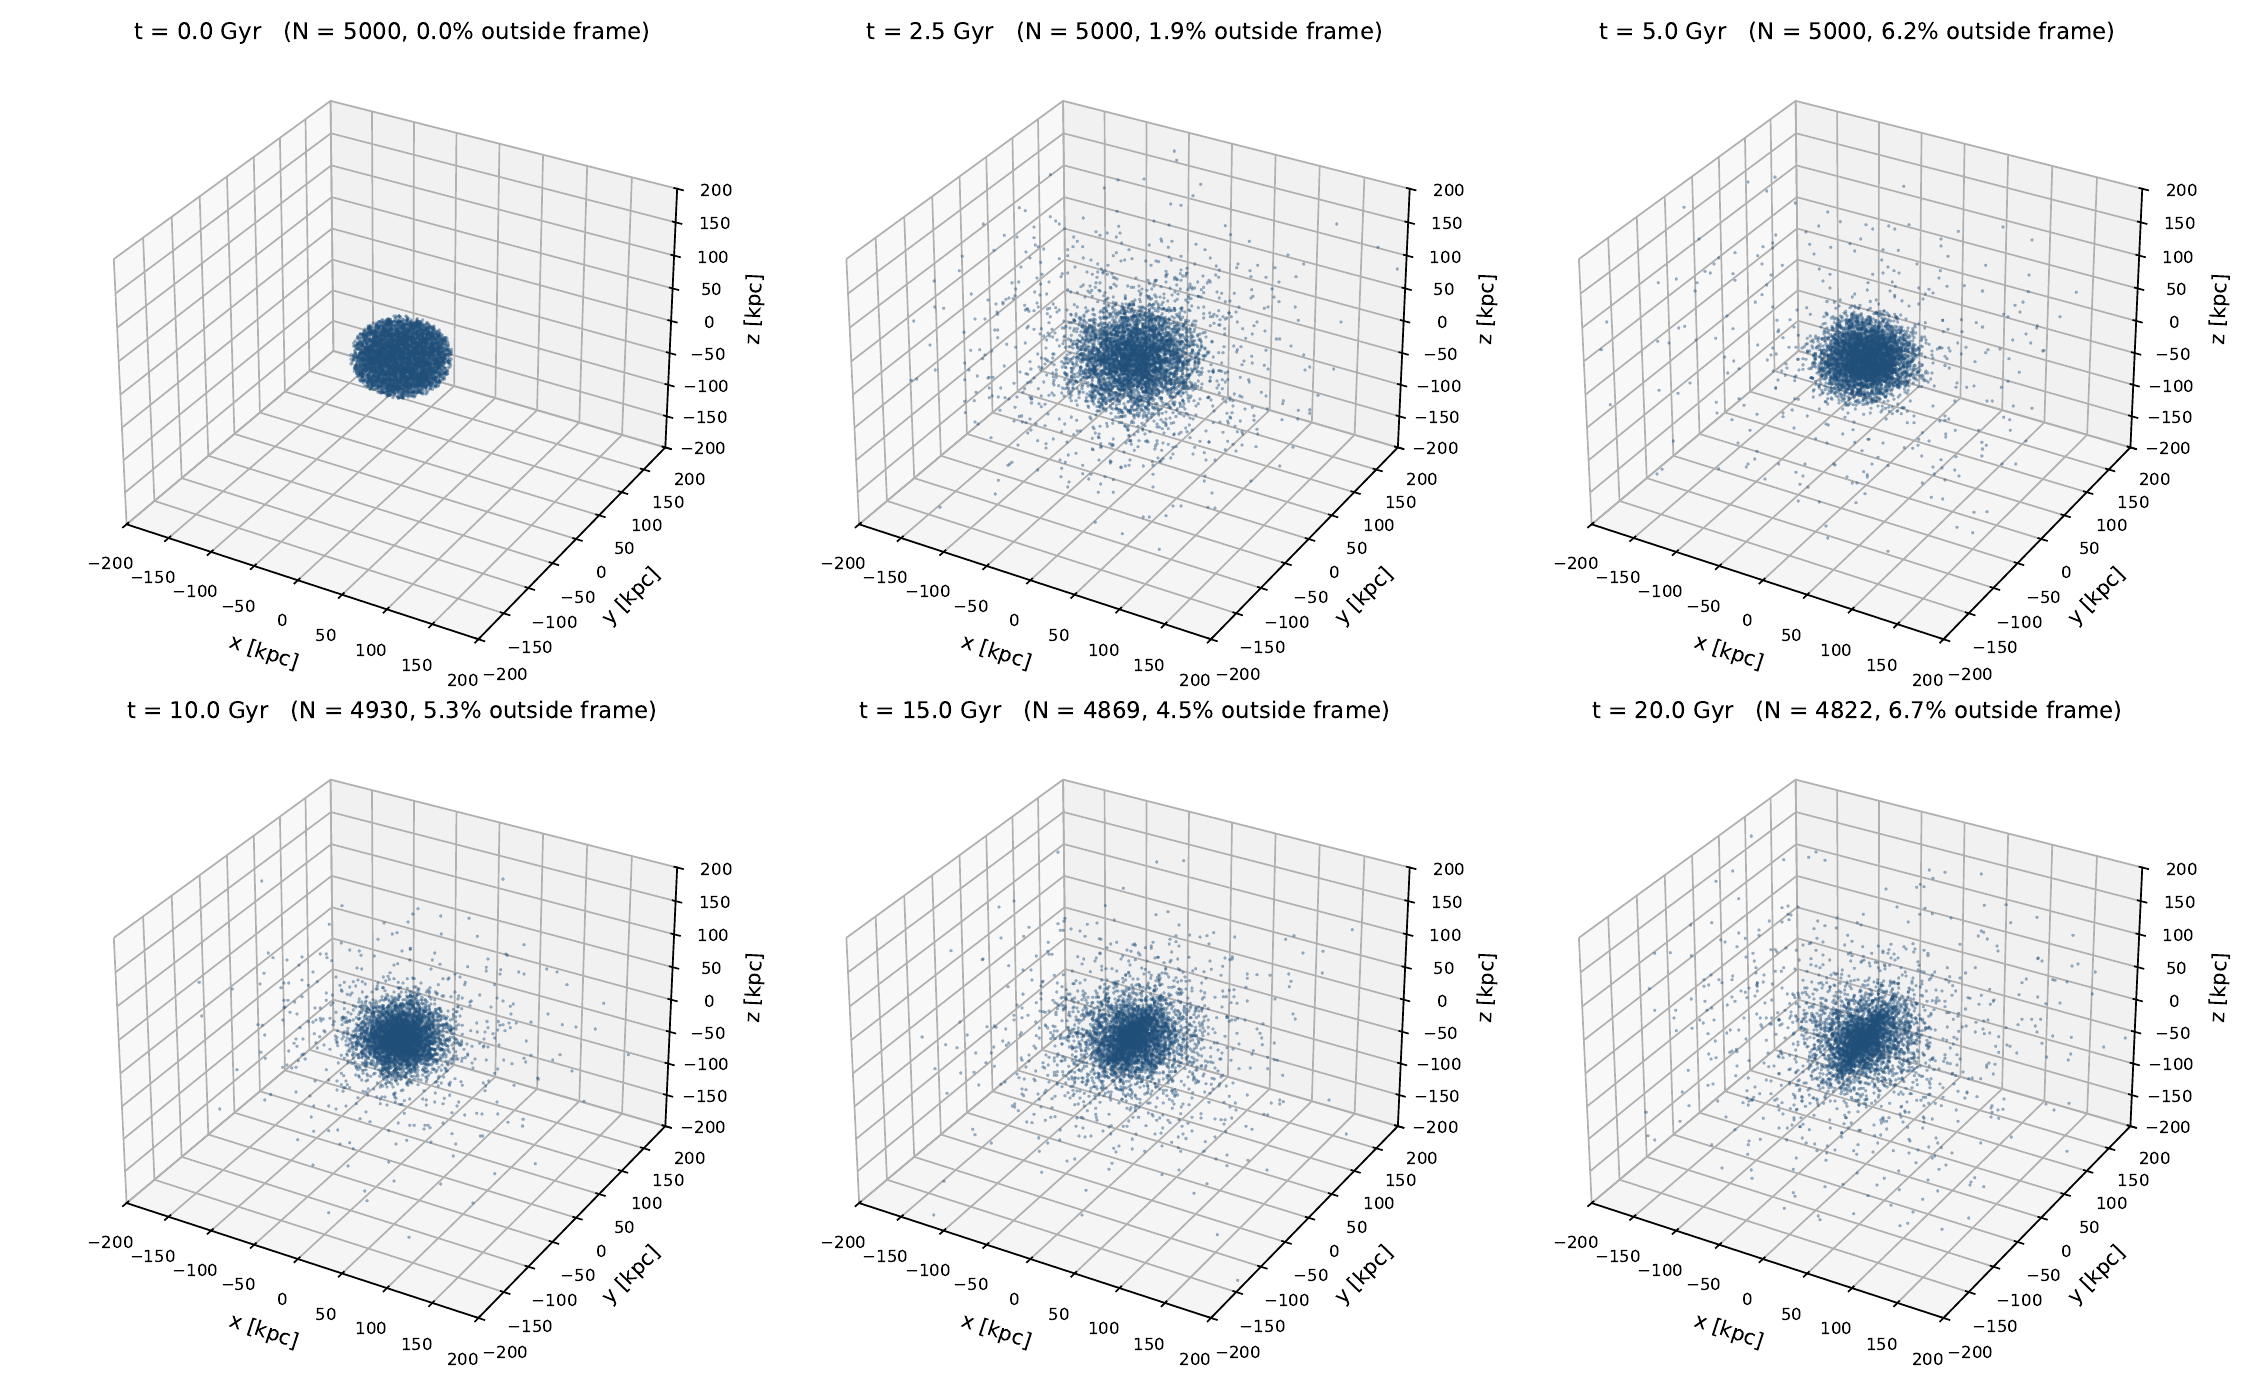

### (b) Relative energy conservation

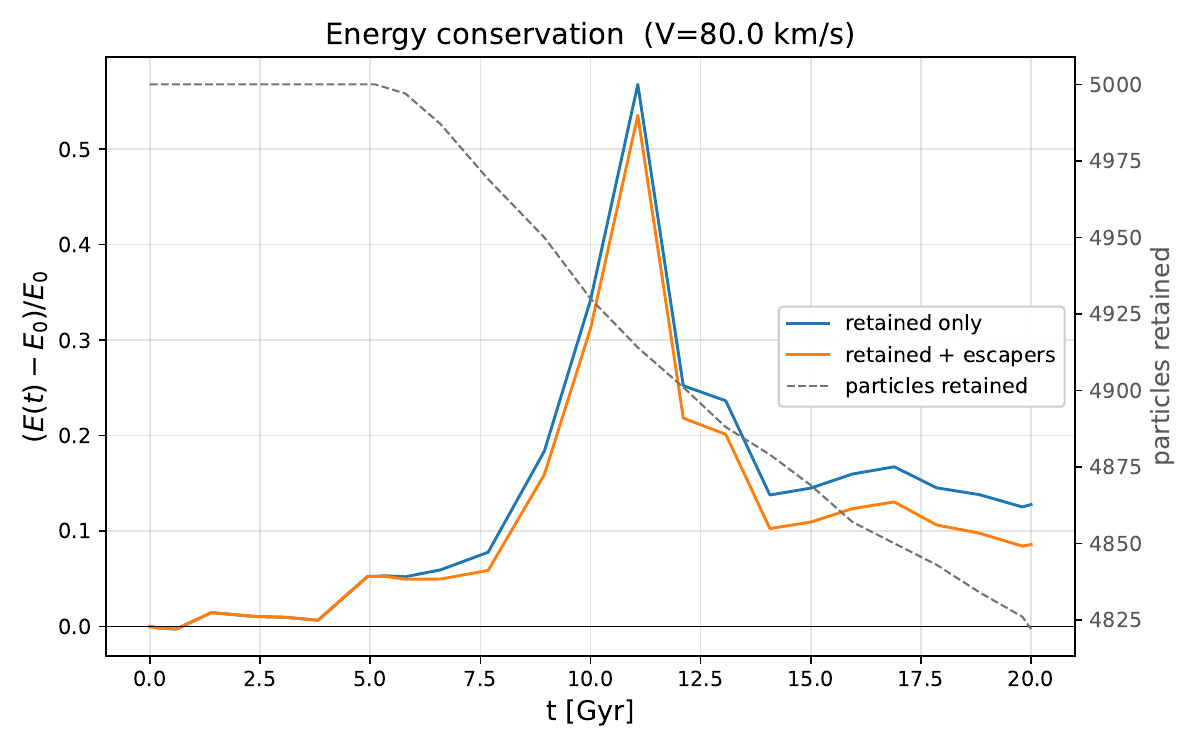

### (c) Virial ratio with and without frozen escaper energy

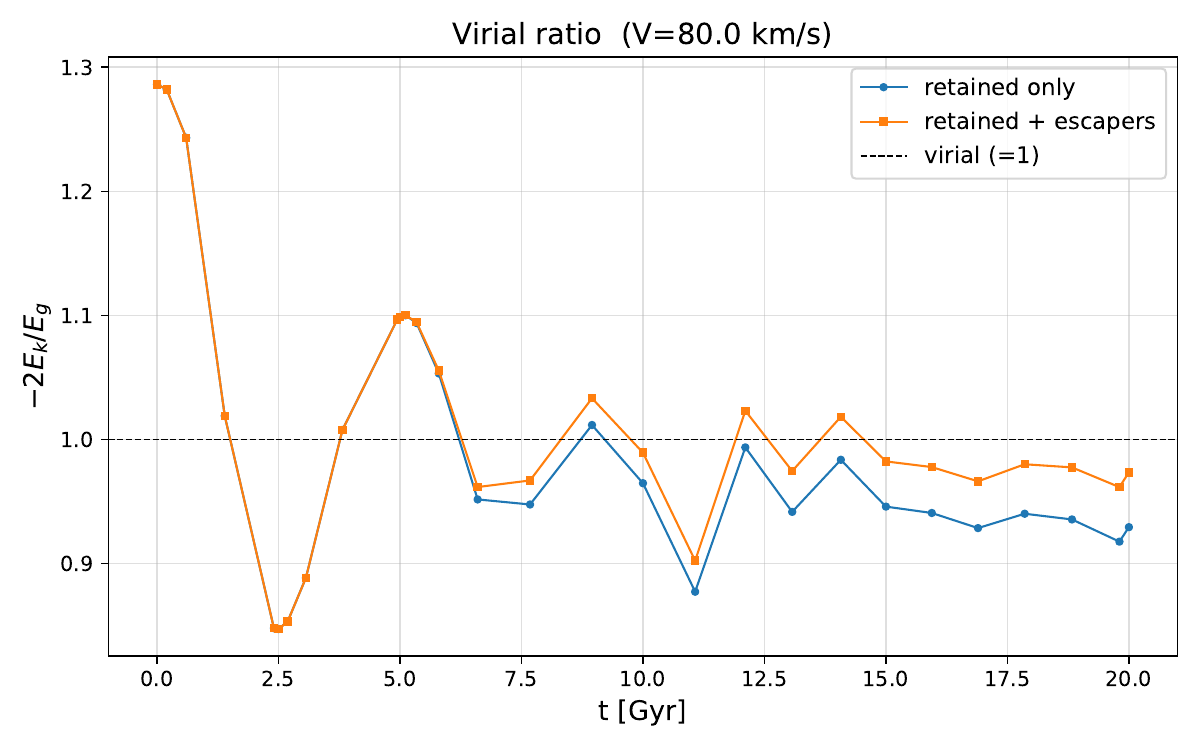

### (d) Final density profiles and common-shape King fits

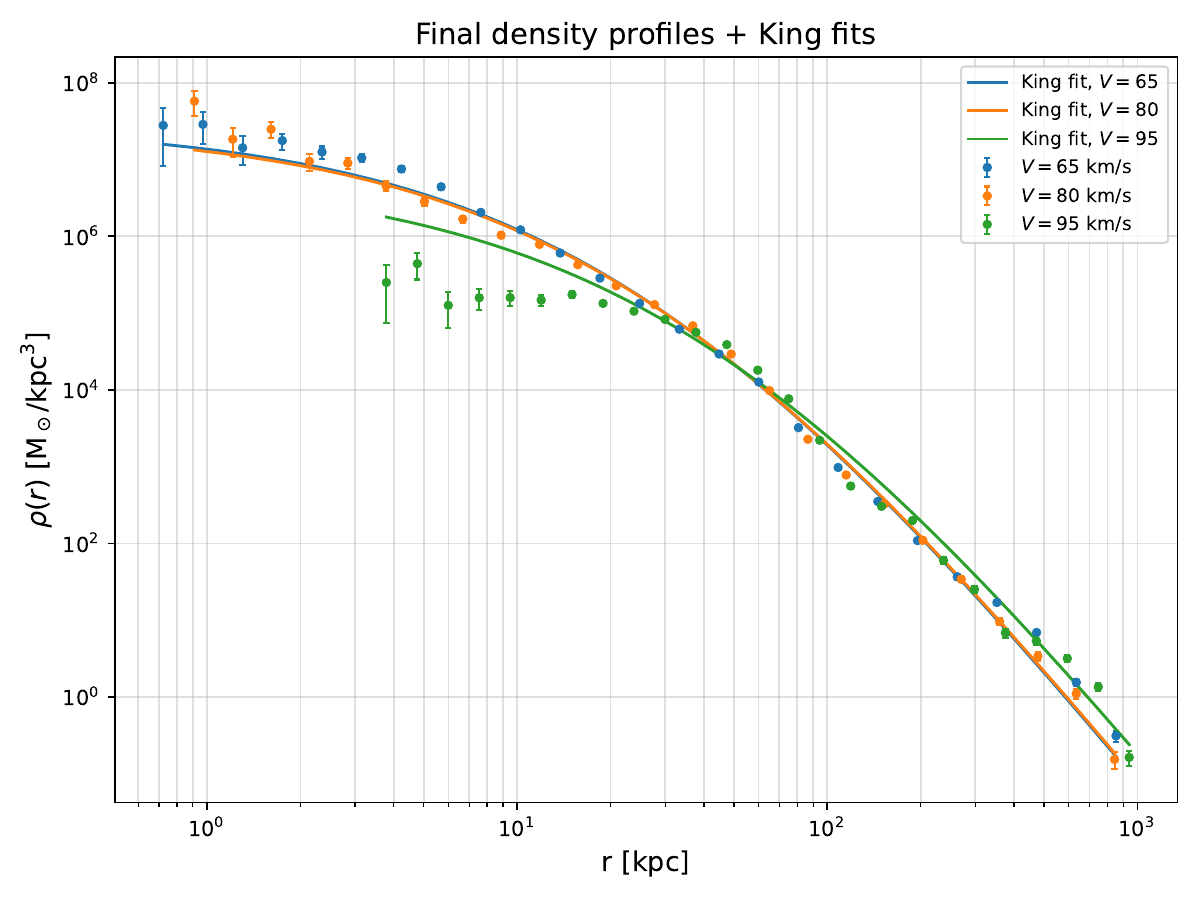

## Summary

The solver uses the assigned uniform sphere, softened force, diagonal cell
criterion at $\theta=1$, adaptive RK4, and box-boundary removal. Direct
summation gives a tree-force error near one percent at the assigned opening
parameter, while the softened-binary test returns to its initial separation with
negligible energy drift.

Each system reaches $-2E_k/E_g\approx1$ within 20 Gyr. The $V=65$ case contracts
and retains almost all its mass. The $V=80$ case expands and loses three percent,
while the $V=95$ case loses fifteen percent. Core radius increases and central
density decreases with initial speed.

The assigned tolerance permits a 133.2 kpc step error, larger than the initial
cluster radius, and produces final energy shifts of 9 to 35 percent. Reducing
the tolerance by $10^3$ keeps the shifts below 0.5 percent. For the saved
$V=80$ runs, this changes the accepted-step count from 28 to 310; wall time is
machine- and load-dependent and is recorded in the generated summaries. The
report presents the tighter results and retains all assigned-tolerance outputs
for comparison.